# CMEMS vs FCOO current-field viewer

Pulls the **latest** CMEMS and FCOO (GETM) forecast runs for the pipeline's
Danish/Baltic region, using the exact same fetch/interpolation functions the
leaderboard pipeline uses in production (`src/data_handler.py`,
`src/simulate.py`) -- no new fetching or interpolation code lives in this
notebook. You pick a **future validity date** within the forecast horizon
that's actually available, and get:

1. the real geographic coverage of each dataset (CMEMS vs FCOO's `dk` +
   nested `idk` grids),
2. full 3D (`time, depth, lat, lon`) current-speed maps at several depths,
   side by side,
3. a model-agreement (difference) map at those same depths, computed by
   querying both models' `simulate.build_interpolators` on one common grid --
   the same interpolation mechanism the pipeline uses to advect floats.

Requires: a working `copernicusmarine` login (same as the production
pipeline) and network access to `data.fcoo.dk`.

In [1]:
from datetime import datetime, timedelta

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
from scipy.interpolate import RegularGridInterpolator

from src import data_handler, simulate, run

plt.rcParams["figure.facecolor"] = "white"

In [2]:
# Same startup sequence run.py itself uses -- loads config.toml and pushes its
# values into data_handler's module globals (dataset id, max depth, region),
# so this notebook fetches exactly what the production pipeline would.
cfg = run._load_config()
run._build_globals(cfg)

REGION = run.REGION
print("Region:", REGION)
print("CMEMS dataset id:", data_handler.CMEMS_DATASET_ID)
print("CMEMS max depth (m):", data_handler.CMEMS_DEPTH_MAX)

Region: Region(lat_min=53.5, lat_max=60.0, lon_min=9.0, lon_max=23.0)
CMEMS dataset id: cmems_mod_bal_phy_anfc_PT1H-i
CMEMS max depth (m): 50.0


## Choosing a target date

`download_model_data` always fetches the **latest** forecast run for each
model -- there's no historical/archive fetch here. FCOO ignores the
`issue_time`/`end_time` window entirely and just returns whatever fixed
window its latest file covers; CMEMS uses the window to bound how much it
downloads.

So "a chosen future date" means: pick a validity time inside the horizon the
*latest* run actually covers -- not an arbitrary date. We fetch the same
horizon `run.py` itself assumes for extending trajectories (`now - 1 day`
through `now + 5 days`, "one full max-cycle horizon"), and `TARGET_DATE`
below gets resolved to the nearest timestamp each model actually has data
for once it's downloaded.

In [10]:
TARGET_DATE = datetime.utcnow() + timedelta(days=1)   # <-- edit this

fetch_start = datetime.utcnow() - timedelta(days=1)
fetch_end = datetime.utcnow() + timedelta(days=5)
print(f"Requesting {TARGET_DATE:%Y-%m-%d %H:%M} UTC "
      f"(fetch window {fetch_start:%Y-%m-%d %H:%M} .. {fetch_end:%Y-%m-%d %H:%M})")

Requesting 2026-07-15 09:06 UTC (fetch window 2026-07-13 09:06 .. 2026-07-19 09:06)


/tmp/ipykernel_63952/2214798083.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  TARGET_DATE = datetime.utcnow() + timedelta(days=1)   # <-- edit this
/tmp/ipykernel_63952/2214798083.py:3: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  fetch_start = datetime.utcnow() - timedelta(days=1)
/tmp/ipykernel_63952/2214798083.py:4: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  fetch_end = datetime.utcnow() + timedelta(days=5)


In [5]:
print("Downloading CMEMS...")
cmems_raw = data_handler.download_model_data(
    "cmems", REGION, issue_time=fetch_start, end_time=fetch_end,
)
cmems_ds = data_handler.trim_to_forecast_only(cmems_raw, fetch_start)


print("\nCMEMS dims:", dict(cmems_ds.sizes))

/home/ddyob/Documents/argo_piloting/model_tracker/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO - 2026-07-14T08:55:45Z - Selected dataset version: "202411"
INFO - 2026-07-14T08:55:45Z - Selected dataset part: "default"
WARNING - 2026-07-14T08:55:45Z - The dataset cmems_mod_bal_phy_anfc_PT1H-i, version '202411', part 'default' is currently being updated. Data after 2026-07-13T12:00:00.000Z may not be up to date.
WARNING - 2026-07-14T08:55:45Z - Some of your subset selection [9.0, 23.0] for the longitude dimension exceed the dataset coordinates [9.041582107543945, 30.208656311035156]
100%|██████████| [08:03<00:00]   
INFO - 2026-07-14T09:03:49Z - Total size of the download: 4.42 GB.



CMEMS dims: {'time': 144, 'depth': 21, 'lat': 195, 'lon': 252}


In [4]:
fcoo_raw = data_handler.download_model_data("fcoo", REGION)
fcoo_ds = data_handler.trim_to_forecast_only(fcoo_raw, fetch_start)

print("FCOO dims:  ", dict(fcoo_ds.sizes))

/home/ddyob/Documents/argo_piloting/model_tracker/.venv/bin/python: No module named pip


FCOO dims:   {'time': 56, 'depth_dk': 10, 'lat_dk': 362, 'lon_dk': 290, 'depth_idk': 6, 'lat_idk': 478, 'lon_idk': 450}


In [17]:
print(fcoo_ds["depth_dk"])

<xarray.DataArray 'depth_dk' (depth_dk: 10)> Size: 80B
array([  5.,  10.,  15.,  20.,  25.,  50.,  75., 100., 150., 200.])
Coordinates:
  * depth_dk  (depth_dk) float64 80B 5.0 10.0 15.0 20.0 ... 100.0 150.0 200.0


## Geographic coverage

Before looking at any current fields, it's worth seeing what area each
source actually covers -- CMEMS's grid, FCOO's coarser `dk` grid (1 nm,
full North Sea + Baltic), and FCOO's finer nested `idk` grid (600 m,
inner-Danish waters only). `idk` is preferred wherever it covers a query
point (see `simulate._build_fcoo_interpolators`); `dk` is the fallback
everywhere else.

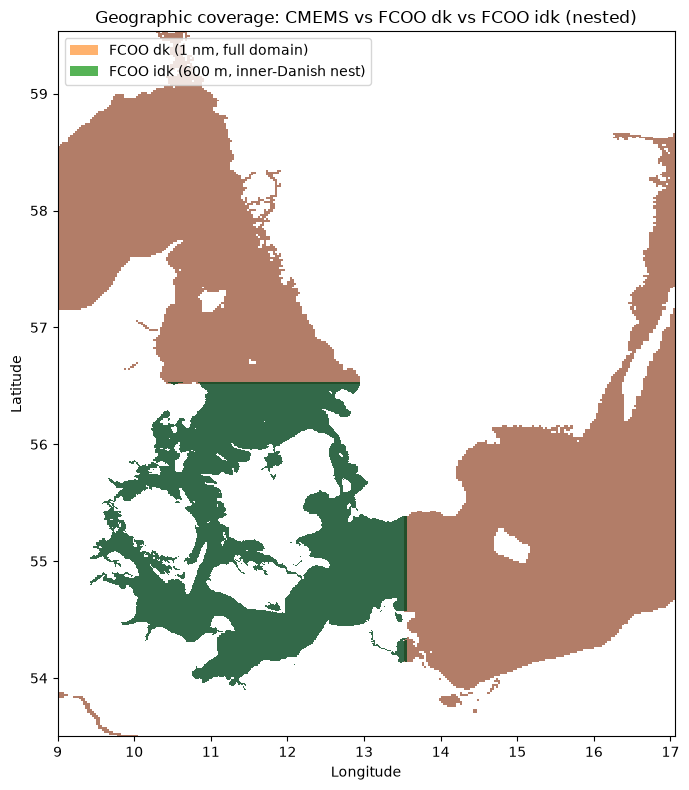

In [8]:
def _coverage(valid):
    """1 where `valid` (a 2-D boolean mask), NaN elsewhere -- for a translucent pcolormesh overlay."""
    return np.where(valid, 1.0, np.nan)


fig, ax = plt.subplots(figsize=(7, 8))

cmems_valid = np.isfinite(cmems_ds["u"].isel(time=0, depth=0).values)
dk_valid = np.isfinite(fcoo_ds["u_dk"].isel(time=0, depth_dk=0).values)
idk_valid = np.isfinite(fcoo_ds["u_idk"].isel(time=0, depth_idk=0).values)

ax.pcolormesh(cmems_ds["lon"], cmems_ds["lat"], _coverage(cmems_valid),
              shading="auto", cmap="Blues", vmin=0, vmax=1, alpha=0.6)
ax.pcolormesh(fcoo_ds["lon_dk"], fcoo_ds["lat_dk"], _coverage(dk_valid),
              shading="auto", cmap="Oranges", vmin=0, vmax=1, alpha=0.6)
ax.pcolormesh(fcoo_ds["lon_idk"], fcoo_ds["lat_idk"], _coverage(idk_valid),
              shading="auto", cmap="Greens", vmin=0, vmax=1, alpha=0.8)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Geographic coverage: CMEMS vs FCOO dk vs FCOO idk (nested)")
ax.legend(handles=[
    Patch(facecolor="tab:blue", alpha=0.6, label="CMEMS"),
    Patch(facecolor="tab:orange", alpha=0.6, label="FCOO dk (1 nm, full domain)"),
    Patch(facecolor="tab:green", alpha=0.8, label="FCOO idk (600 m, inner-Danish nest)"),
], loc="upper left")
fig.tight_layout()

In [11]:
target_np = np.datetime64(TARGET_DATE.replace(tzinfo=None), "ns")

cmems_at = cmems_ds.sel(time=target_np, method="nearest")
fcoo_at = fcoo_ds.sel(time=target_np, method="nearest")

cmems_t = cmems_at["time"].values
fcoo_t = fcoo_at["time"].values
print(f"Requested:     {TARGET_DATE:%Y-%m-%d %H:%M} UTC")
print(f"CMEMS nearest: {np.datetime_as_string(cmems_t, unit='m')}")
print(f"FCOO nearest:  {np.datetime_as_string(fcoo_t, unit='m')}")

for name, t in [("CMEMS", cmems_t), ("FCOO", fcoo_t)]:
    off_hours = abs((t - target_np) / np.timedelta64(1, "h"))
    if off_hours > 6:
        print(f"WARNING: {name}'s nearest available timestep is {off_hours:.1f} h "
              f"from the requested date -- TARGET_DATE may be outside its actual coverage.")

Requested:     2026-07-15 09:06 UTC
CMEMS nearest: 2026-07-15T09:00
FCOO nearest:  2026-07-15T09:00


## Current-speed maps

Same layout as the pipeline's existing quick-look comparison
(`fcoo_cmems_speed.png`): FCOO vs CMEMS side by side, one row per depth,
sharing one color scale per row so the two are directly comparable by eye.
FCOO's `idk` nest is drawn on top of `dk`, matching
`notebooks/fcoo_model_viewer.py`.

In [ ]:
TARGET_DEPTHS = [0.0, 5.0, 20.0, 80.0]  # metres

fig, axes = plt.subplots(len(TARGET_DEPTHS), 2, figsize=(11, 3.6 * len(TARGET_DEPTHS)))

for row, depth in enumerate(TARGET_DEPTHS):
    cmems_d = cmems_at.sel(depth=depth, method="nearest")
    dk_d = fcoo_at.sel(depth_dk=depth, method="nearest")
    idk_d = fcoo_at.sel(depth_idk=depth, method="nearest")

    speed_cmems = np.hypot(cmems_d["u"].values, cmems_d["v"].values)
    speed_dk = np.hypot(dk_d["u_dk"].values, dk_d["v_dk"].values)
    speed_idk = np.hypot(idk_d["u_idk"].values, idk_d["v_idk"].values)

    vmax = np.nanmax([np.nanmax(speed_cmems), np.nanmax(speed_dk), np.nanmax(speed_idk)])

    ax_fcoo, ax_cmems = axes[row]
    for ax in (ax_fcoo, ax_cmems):
        ax.set_facecolor("0.8")  # NaN (land) cells show through as grey

    ax_fcoo.pcolormesh(fcoo_ds["lon_dk"], fcoo_ds["lat_dk"], speed_dk,
                        shading="auto", cmap="viridis", vmin=0, vmax=vmax)
    ax_fcoo.pcolormesh(fcoo_ds["lon_idk"], fcoo_ds["lat_idk"], speed_idk,
                        shading="auto", cmap="viridis", vmin=0, vmax=vmax)
    mesh = ax_cmems.pcolormesh(cmems_ds["lon"], cmems_ds["lat"], speed_cmems,
                                shading="auto", cmap="viridis", vmin=0, vmax=vmax)

    ax_fcoo.set_title(f"FCOO |V|, depth={depth:.0f} m")
    ax_cmems.set_title(f"CMEMS |V|, depth={depth:.0f} m")
    for ax in (ax_fcoo, ax_cmems):
        ax.set_xlabel("Longitude")
    ax_fcoo.set_ylabel("Latitude")
    fig.colorbar(mesh, ax=ax_cmems, shrink=0.85, label="m/s")

fig.suptitle(f"Current speed at {np.datetime_as_string(cmems_t, unit='h')}", y=1.0)
fig.tight_layout()
fig.savefig("current_speed.png")

## Model agreement (difference maps)

To subtract two models' currents at the *same* point, both need evaluating
at one common set of points -- this is exactly what
`simulate.build_interpolators` builds a `RegularGridInterpolator` pair for,
already used elsewhere in the pipeline to advect floats through whichever
model is being tested. We reuse it here as-is rather than re-implementing
scattered-point interpolation (the old notebook used
`scipy.interpolate.griddata` for this; the pipeline's own mechanism is more
appropriate since it's the same interpolation the leaderboard's scoring
actually relies on).

Both interpolators return `fill_value=0.0` outside their real coverage
(land, or beyond a grid's domain) rather than `NaN`, so a "zero difference"
near land/domain edges would actually reflect *no current data*, not model
agreement -- land is masked separately below using CMEMS's own native grid.

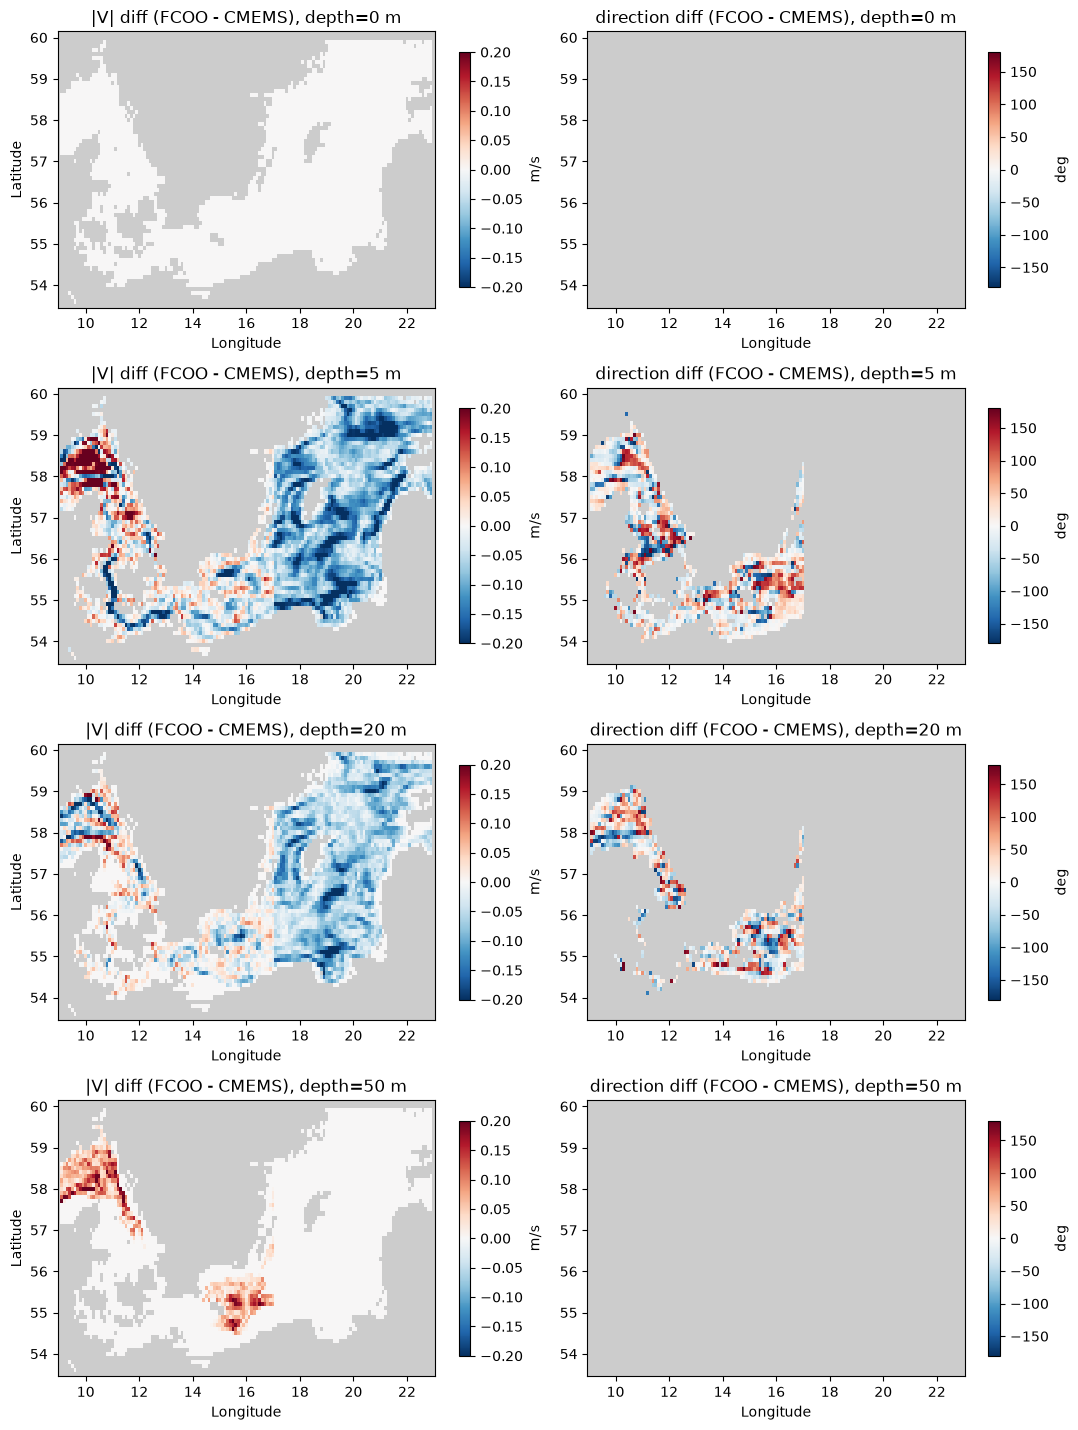

In [14]:
GRID_RES_DEG = 0.1  # common grid resolution for the diff maps

lat_grid = np.arange(REGION.lat_min, REGION.lat_max + GRID_RES_DEG, GRID_RES_DEG)
lon_grid = np.arange(REGION.lon_min, REGION.lon_max + GRID_RES_DEG, GRID_RES_DEG)
LON, LAT = np.meshgrid(lon_grid, lat_grid)
n_pts = LON.size

t_s = cmems_t.astype("datetime64[s]").astype(np.float64)

interp_u_cmems, interp_v_cmems = simulate.build_interpolators(cmems_ds)
interp_u_fcoo, interp_v_fcoo = simulate.build_interpolators(fcoo_ds)

# Cosmetic land mask, nearest-neighbour from CMEMS's own native NaN footprint
# (the interpolators above fill 0.0 for land, which isn't distinguishable
# from "real zero current" -- this mask is purely for shading, not physics).
land_mask_interp = RegularGridInterpolator(
    (cmems_ds["lat"].values, cmems_ds["lon"].values),
    np.isnan(cmems_ds["u"].isel(time=0, depth=0).values).astype(float),
    method="nearest", bounds_error=False, fill_value=1.0,
)
is_land = land_mask_interp(np.column_stack([LAT.ravel(), LON.ravel()])).reshape(LAT.shape) > 0.5

MIN_SPEED_FOR_DIRECTION = 0.02  # m/s

fig, axes = plt.subplots(len(TARGET_DEPTHS), 2, figsize=(11, 3.6 * len(TARGET_DEPTHS)))

for row, depth in enumerate(TARGET_DEPTHS):
    rows = np.column_stack([
        np.full(n_pts, t_s), np.full(n_pts, depth), LAT.ravel(), LON.ravel(),
    ])
    u_c = interp_u_cmems(rows).reshape(LAT.shape)
    v_c = interp_v_cmems(rows).reshape(LAT.shape)
    u_f = interp_u_fcoo(rows).reshape(LAT.shape)
    v_f = interp_v_fcoo(rows).reshape(LAT.shape)

    speed_c = np.hypot(u_c, v_c)
    speed_f = np.hypot(u_f, v_f)
    speed_diff = np.where(is_land, np.nan, speed_f - speed_c)

    dir_c = np.degrees(np.arctan2(u_c, v_c)) % 360
    dir_f = np.degrees(np.arctan2(u_f, v_f)) % 360
    dir_diff = ((dir_f - dir_c + 180) % 360) - 180
    weak = (speed_c < MIN_SPEED_FOR_DIRECTION) | (speed_f < MIN_SPEED_FOR_DIRECTION)
    dir_diff = np.where(is_land | weak, np.nan, dir_diff)

    ax_speed, ax_dir = axes[row]
    for ax in (ax_speed, ax_dir):
        ax.set_facecolor("0.8")

    mesh_speed = ax_speed.pcolormesh(
        lon_grid, lat_grid, speed_diff, shading="auto", cmap="RdBu_r",
        norm=TwoSlopeNorm(vcenter=0, vmin=-0.2, vmax=0.2),
    )
    mesh_dir = ax_dir.pcolormesh(
        lon_grid, lat_grid, dir_diff, shading="auto", cmap="RdBu_r",
        norm=TwoSlopeNorm(vcenter=0, vmin=-180, vmax=180),
    )
    ax_speed.set_title(f"|V| diff (FCOO - CMEMS), depth={depth:.0f} m")
    ax_dir.set_title(f"direction diff (FCOO - CMEMS), depth={depth:.0f} m")
    for ax in (ax_speed, ax_dir):
        ax.set_xlabel("Longitude")
    ax_speed.set_ylabel("Latitude")
    fig.colorbar(mesh_speed, ax=ax_speed, shrink=0.85, label="m/s")
    fig.colorbar(mesh_dir, ax=ax_dir, shrink=0.85, label="deg")

fig.tight_layout()
fig.savefig("output.png")

## Caveats

- FCOO's `download_model_data` call ignores `issue_time`/`end_time` -- it
  always returns whatever fixed window the latest `dk_nested.velocities.Z3D_*`
  file covers. If `TARGET_DATE` falls outside that window (see the
  "resolve target date" warning above), you're comparing the *nearest*
  timestep FCOO actually has, not your requested one.
- Wherever FCOO's `idk` nest covers a query point, it's preferred over `dk`
  (`simulate._build_fcoo_interpolators`); `dk` is only used outside `idk`'s
  bounding box.
- The diff maps' interpolators return `fill_value=0.0` for points outside a
  grid's real coverage (land, or beyond CMEMS's/FCOO's domain) -- that's why
  a separate land mask is used for shading rather than trusting "diff == 0"
  to mean land.
- CMEMS depth here is real vertical levels down to
  `data_handler.CMEMS_DEPTH_MAX`; FCOO's `dk`/`idk` depths are each grid's own
  real levels (10 levels 5-200 m for `dk`, 6 levels 5-50 m for `idk`) -- no
  fabricated/duplicated depth axis on either side.